# **Day 26: GLMs, Robust Regression and Quantile Regression**
*Module 4 - Regression*

Ordinary least squares assumes a continuous, unbounded, normally distributed target with constant variance. Real targets are often **counts** (number of landslides, insurance claims), **positive and skewed** (rainfall, costs), **proportions**, contaminated by **outliers**, or we need **ranges** rather than means. Today's tools handle all of these.

> Ordinary regression assumes normal errors and cares only about the mean. GLMs handle counts and proportions, robust regression resists outliers, and quantile regression predicts other parts of the distribution, such as the 10th or 90th percentile.
>
> *Example:* To predict the number of fire hotspots per grid cell (a count), Poisson regression is more suitable than a straight line, which could even predict negative fires.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
rng = np.random.default_rng(26)

## **1. Generalised Linear Models**
A GLM has three parts:
1. A **distribution** for $y$ from the exponential family (Normal, Poisson, Gamma, Binomial, ...).
2. A **linear predictor** $\eta = \mathbf x^\top\boldsymbol\beta$.
3. A **link function** $g(\mu) = \eta$ connecting the mean to the linear predictor.

| Target | Distribution | Link | Model |
|---|---|---|---|
| Continuous | Normal | identity | Linear regression |
| Binary | Binomial | logit | Logistic regression (Day 27) |
| Counts | Poisson / Neg. Binomial | log | Poisson regression |
| Positive, skewed | Gamma | log | Gamma regression |
| Zeros + positive continuous | Tweedie | log | Insurance claims, rainfall |

The **log link** makes effects multiplicative: $e^{\beta_j}$ is the factor by which the mean changes per unit of $x_j$.

## **2. Poisson Regression for Counts**
Example: number of landslides per watershed as a function of slope, rainfall and road density. Watersheds have different areas, so we include log(area) as an **offset** (we model a **rate** per km^2).

In [2]:
n = 400
ws = pd.DataFrame({"slope_deg": rng.uniform(5, 40, n), "rain_m": rng.uniform(1.0, 3.5, n),
                   "road_km_per_km2": rng.gamma(2, 0.4, n), "area_km2": rng.uniform(5, 80, n)})
log_rate = -6.0 + 0.08 * ws.slope_deg + 0.5 * ws.rain_m + 0.4 * ws.road_km_per_km2
ws["landslides"] = rng.poisson(np.exp(log_rate) * ws.area_km2)
print(ws.landslides.describe().round(2))

pois = smf.glm("landslides ~ slope_deg + rain_m + road_km_per_km2", data=ws, family=sm.families.Poisson(),
               offset=np.log(ws.area_km2)).fit()
print(pois.summary().tables[1])
print("\nRate ratios exp(beta):\n", np.exp(pois.params).round(3))

count    400.00
mean       4.03
std        5.16
min        0.00
25%        1.00
50%        2.00
75%        5.00
max       32.00
Name: landslides, dtype: float64
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -6.1143      0.136    -45.122      0.000      -6.380      -5.849
slope_deg           0.0870      0.003     29.680      0.000       0.081       0.093
rain_m              0.4518      0.034     13.259      0.000       0.385       0.519
road_km_per_km2     0.4186      0.035     11.997      0.000       0.350       0.487

Rate ratios exp(beta):
 Intercept          0.002
slope_deg          1.091
rain_m             1.571
road_km_per_km2    1.520
dtype: float64


**Interpretation:** each extra degree of slope multiplies the landslide rate by ~1.08 (+8%), holding the others constant.

### Why not OLS on counts?

In [3]:
ols = smf.ols("landslides ~ slope_deg + rain_m + road_km_per_km2 + area_km2", data=ws).fit()
print("OLS negative predictions:", (ols.fittedvalues < 0).sum(), "of", n)
print(f"Poisson deviance: OLS-based (clipped) {sm.families.Poisson().deviance(ws.landslides, ols.fittedvalues.clip(0.01)):.1f} | Poisson GLM {pois.deviance:.1f}")

OLS negative predictions: 75 of 400
Poisson deviance: OLS-based (clipped) 816.8 | Poisson GLM 385.5


### Overdispersion and the Negative Binomial
Poisson assumes variance = mean. Real counts usually have **more** variance (unobserved heterogeneity, clustering). Check the dispersion statistic: Pearson $\chi^2$ / df $\approx 1$ for Poisson.

In [4]:
heterogeneity = rng.gamma(1.5, 1 / 1.5, n)                         # unobserved factors (geology, ...)
ws["landslides_od"] = rng.poisson(np.exp(log_rate) * ws.area_km2 * heterogeneity)
p_od = smf.glm("landslides_od ~ slope_deg + rain_m + road_km_per_km2", data=ws, family=sm.families.Poisson(), offset=np.log(ws.area_km2)).fit()
nb = smf.glm("landslides_od ~ slope_deg + rain_m + road_km_per_km2", data=ws, family=sm.families.NegativeBinomial(alpha=1 / 1.5), offset=np.log(ws.area_km2)).fit()
print(f"Dispersion (Pearson chi2/df): Poisson fit = {p_od.pearson_chi2 / p_od.df_resid:.2f}  (>> 1 means overdispersed)")
print(pd.DataFrame({"Poisson SE": p_od.bse, "NegBin SE": nb.bse}).round(4))
print("Poisson standard errors are too small -> false 'significance'. Use Negative Binomial (or quasi-Poisson).")

Dispersion (Pearson chi2/df): Poisson fit = 4.48  (>> 1 means overdispersed)
                 Poisson SE  NegBin SE
Intercept            0.1273     0.2548
slope_deg            0.0027     0.0055
rain_m               0.0330     0.0738
road_km_per_km2      0.0316     0.0883
Poisson standard errors are too small -> false 'significance'. Use Negative Binomial (or quasi-Poisson).


## **3. Gamma and Tweedie Regression (scikit-learn)**
scikit-learn has GLMs with regularisation: `PoissonRegressor`, `GammaRegressor`, `TweedieRegressor`. Evaluate with the matching **deviance**, not MSE.

In [5]:
from sklearn.linear_model import PoissonRegressor, GammaRegressor, TweedieRegressor, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_poisson_deviance, mean_gamma_deviance, mean_tweedie_deviance, root_mean_squared_error

Xg = rng.normal(size=(3000, 4)); mu = np.exp(1 + Xg @ [0.5, -0.3, 0.2, 0.0])
y_gamma = rng.gamma(shape=2.0, scale=mu / 2.0)                     # positive, skewed, variance grows with mean
Xa, Xb, ya, yb = train_test_split(Xg, y_gamma, random_state=0)
for name, m in [("OLS", LinearRegression()), ("Gamma GLM", GammaRegressor(alpha=0)), ("Tweedie (power=2)", TweedieRegressor(power=2, link="log", alpha=0))]:
    pr = m.fit(Xa, ya).predict(Xb)
    dev = mean_gamma_deviance(yb, np.clip(pr, 1e-3, None))
    print(f"{name:<18} RMSE {root_mean_squared_error(yb, pr):.3f} | Gamma deviance {dev:.4f} | negative preds: {(pr <= 0).sum()}")

OLS                RMSE 3.107 | Gamma deviance 66.8140 | negative preds: 35


Gamma GLM          RMSE 3.026 | Gamma deviance 0.5576 | negative preds: 0
Tweedie (power=2)  RMSE 3.026 | Gamma deviance 0.5576 | negative preds: 0


## **4. Robust Regression**
A few gross errors (instrument failures, mislabelled samples) can tilt OLS completely.

| Method | Idea | Breakdown point |
|---|---|---|
| **Huber** | Quadratic loss for small residuals, linear for large ones | Moderate (y-outliers) |
| **RANSAC** | Fit on random subsets; keep the model with most inliers | High |
| **Theil-Sen** | Median of slopes over pairs of points | ~29% |

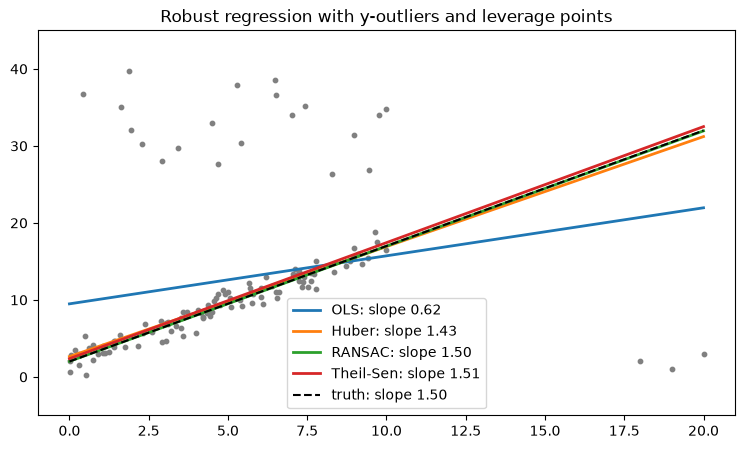

In [6]:
from sklearn.linear_model import HuberRegressor, RANSACRegressor, TheilSenRegressor
x = rng.uniform(0, 10, 120); y_r = 2 + 1.5 * x + rng.normal(0, 1, 120)
out = rng.choice(120, 20, replace=False); y_r[out] = rng.uniform(25, 40, 20)       # 17% gross outliers
x_lev = np.r_[x, [18, 19, 20]]; y_lev = np.r_[y_r, [2, 1, 3]]                       # + 3 high-leverage outliers
xs = np.linspace(0, 20, 50)[:, None]
plt.figure(figsize=(9, 5)); plt.scatter(x_lev, y_lev, s=10, c="grey")
for name, m in [("OLS", LinearRegression()), ("Huber", HuberRegressor()), ("RANSAC", RANSACRegressor(random_state=0)),
                ("Theil-Sen", TheilSenRegressor(random_state=0))]:
    m.fit(x_lev[:, None], y_lev)
    slope = m.estimator_.coef_[0] if name == "RANSAC" else m.coef_[0]
    plt.plot(xs, m.predict(xs), lw=2, label=f"{name}: slope {slope:.2f}")
plt.plot(xs, 2 + 1.5 * xs, "k--", label="truth: slope 1.50"); plt.legend(); plt.ylim(-5, 45); plt.title("Robust regression with y-outliers and leverage points"); plt.show()

## **5. Quantile Regression**
OLS predicts the **mean**. Quantile regression predicts any **quantile** $\tau$ by minimising the pinball loss (Day 14). Uses: prediction ranges, effects that differ between low and high values (e.g. fertiliser helps poor fields more), heteroscedastic data.

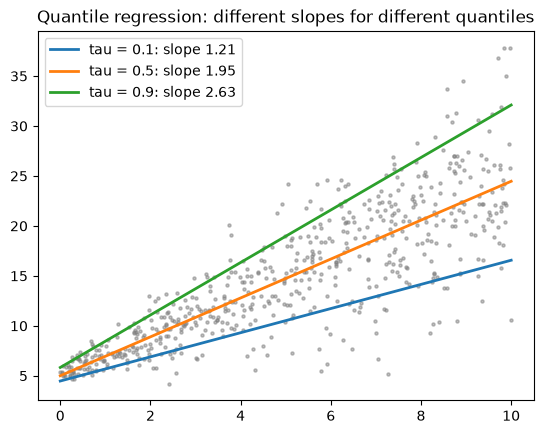

In [7]:
xq = rng.uniform(0, 10, 600)
yq = 5 + 2 * xq + rng.normal(0, 0.5 + 0.6 * xq, 600)                  # spread increases with x
dq = pd.DataFrame({"x": xq, "y": yq})
plt.scatter(xq, yq, s=5, c="grey", alpha=0.5)
xs1 = np.linspace(0, 10, 50)
for tau, c in [(0.1, "C0"), (0.5, "C1"), (0.9, "C2")]:
    qr = smf.quantreg("y ~ x", dq).fit(q=tau)
    plt.plot(xs1, qr.params["Intercept"] + qr.params["x"] * xs1, c, lw=2, label=f"tau = {tau}: slope {qr.params['x']:.2f}")
plt.legend(); plt.title("Quantile regression: different slopes for different quantiles"); plt.show()

The 90th-percentile line is steeper than the 10th: the effect of $x$ on high outcomes is larger. OLS (the mean) would hide this.

### Prediction intervals from quantile models

In [8]:
from sklearn.linear_model import QuantileRegressor
Xq_tr, Xq_te, yq_tr, yq_te = train_test_split(xq[:, None], yq, test_size=0.3, random_state=0)
lo = QuantileRegressor(quantile=0.05, alpha=0, solver="highs").fit(Xq_tr, yq_tr).predict(Xq_te)
hi = QuantileRegressor(quantile=0.95, alpha=0, solver="highs").fit(Xq_tr, yq_tr).predict(Xq_te)
print(f"Empirical coverage of the 90% interval on test data: {np.mean((yq_te >= lo) & (yq_te <= hi)):.3f}")

Empirical coverage of the 90% interval on test data: 0.911


# **Part 2: Going Deeper**

### Non-linear quantile regression with gradient boosting
`HistGradientBoostingRegressor(loss="quantile")` models non-linear quantiles.

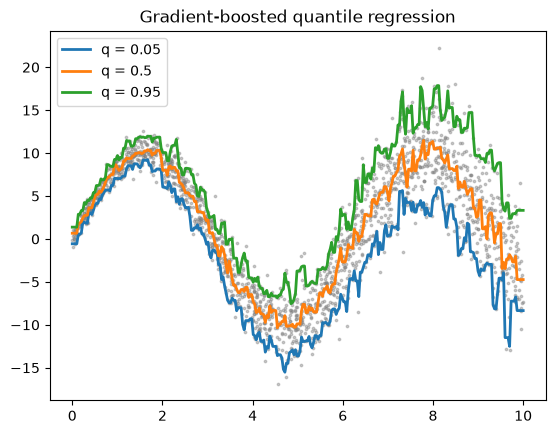

In [9]:
from sklearn.ensemble import HistGradientBoostingRegressor
xn = rng.uniform(0, 10, 2000); yn = 10 * np.sin(xn) + rng.normal(0, 0.5 + 0.4 * xn, 2000)
grid = np.linspace(0, 10, 300)[:, None]
plt.scatter(xn, yn, s=3, c="grey", alpha=0.4)
for q in [0.05, 0.5, 0.95]:
    m = HistGradientBoostingRegressor(loss="quantile", quantile=q, max_iter=300, random_state=0).fit(xn[:, None], yn)
    plt.plot(grid, m.predict(grid), lw=2, label=f"q = {q}")
plt.legend(); plt.title("Gradient-boosted quantile regression"); plt.show()

### Zero-inflation
Some counts have **excess zeros** because two processes are at work (e.g. many watersheds are geologically stable and *can't* have landslides). A **zero-inflated Poisson** mixes a point mass at zero with a Poisson.

In [10]:
from statsmodels.discrete.count_model import ZeroInflatedPoisson
stable = rng.random(n) < 0.4
ws["ls_zi"] = np.where(stable, 0, rng.poisson(np.exp(log_rate) * ws.area_km2))
exog = sm.add_constant(ws[["slope_deg", "rain_m", "road_km_per_km2"]])
zip_m = ZeroInflatedPoisson(ws.ls_zi, exog, exog_infl=np.ones((n, 1)), offset=np.log(ws.area_km2)).fit(disp=0, maxiter=500)
p_plain = sm.GLM(ws.ls_zi, exog, family=sm.families.Poisson(), offset=np.log(ws.area_km2)).fit()
print(f"Observed zeros: {(ws.ls_zi == 0).mean():.2f}")
print(f"Zeros expected by plain Poisson: {np.mean(np.exp(-p_plain.fittedvalues)):.2f}")
print(f"Estimated structural-zero probability (ZIP): {1 / (1 + np.exp(-zip_m.params.iloc[0])):.2f} (true 0.40)")
print(f"AIC Poisson {p_plain.aic:.0f} vs ZIP {zip_m.aic:.0f} (lower is better)")

Observed zeros: 0.51
Zeros expected by plain Poisson: 0.32
Estimated structural-zero probability (ZIP): 0.39 (true 0.40)
AIC Poisson 1734 vs ZIP 1240 (lower is better)


### Deviance and pseudo-R^2
For GLMs, the analogue of the residual sum of squares is the **deviance**. A pseudo-R^2 is $1 - D_{model}/D_{null}$ (`D2` scores in scikit-learn: `d2_tweedie_score`).

In [11]:
print(f"Poisson GLM pseudo-R2 (deviance explained): {1 - pois.deviance / pois.null_deviance:.3f}")

Poisson GLM pseudo-R2 (deviance explained): 0.768


## **Practice Problems**
1. Fit the landslide Poisson model **without** the offset. How do the coefficients change, and why is that wrong?
2. Use `PoissonRegressor` from scikit-learn on the landslide data (features + `log(area)` as a feature) and report the mean Poisson deviance on a test split.
3. Compare OLS and Theil-Sen slopes when 40% of the data are outliers. Which breaks?
4. *(Advanced)* Fit quantile regression for tau = 0.1, ..., 0.9 and plot the slope vs tau with its confidence interval.

Intercept with offset: -6.11 | without: -2.49 -> area differences are absorbed into noise
Test mean Poisson deviance: 0.998 | log_area coef (should be ~1): 0.882
40% outliers -> OLS slope 0.32 | Theil-Sen 1.46


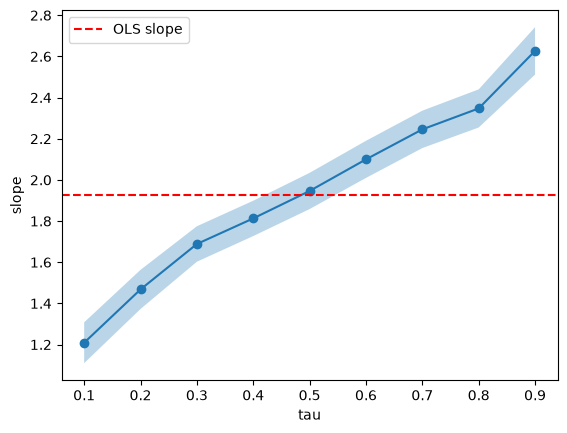

In [12]:
# Solution 1
no_off = smf.glm("landslides ~ slope_deg + rain_m + road_km_per_km2", data=ws, family=sm.families.Poisson()).fit()
print("Intercept with offset:", pois.params.Intercept.round(2), "| without:", no_off.params.Intercept.round(2), "-> area differences are absorbed into noise")
# Solution 2
Xp = ws[["slope_deg", "rain_m", "road_km_per_km2"]].assign(log_area=np.log(ws.area_km2))
Xa2, Xb2, ya2, yb2 = train_test_split(Xp, ws.landslides, random_state=0)
pr2 = PoissonRegressor(alpha=0, max_iter=1000).fit(Xa2, ya2)
print("Test mean Poisson deviance:", round(mean_poisson_deviance(yb2, pr2.predict(Xb2)), 3), "| log_area coef (should be ~1):", pr2.coef_[-1].round(3))
# Solution 3
y40 = 2 + 1.5 * x + rng.normal(0, 1, 120); y40[rng.choice(120, 48, replace=False)] = rng.uniform(25, 40, 48)
print("40% outliers -> OLS slope", LinearRegression().fit(x[:, None], y40).coef_[0].round(2), "| Theil-Sen", TheilSenRegressor(random_state=0).fit(x[:, None], y40).coef_[0].round(2))
# Solution 4
taus = np.arange(0.1, 0.91, 0.1); est = [smf.quantreg("y ~ x", dq).fit(q=t) for t in taus]
plt.plot(taus, [e.params["x"] for e in est], "o-")
plt.fill_between(taus, [e.conf_int().loc["x", 0] for e in est], [e.conf_int().loc["x", 1] for e in est], alpha=0.3)
plt.axhline(smf.ols("y ~ x", dq).fit().params["x"], c="r", ls="--", label="OLS slope"); plt.xlabel("tau"); plt.ylabel("slope"); plt.legend(); plt.show()

## **Key References**
- Nelder, J. A., & Wedderburn, R. W. M. (1972). Generalized linear models. *Journal of the Royal Statistical Society A*, 135(3), 370-384.
- McCullagh, P., & Nelder, J. A. (1989). *Generalized Linear Models* (2nd ed.). Chapman & Hall.
- Koenker, R., & Bassett, G. (1978). Regression quantiles. *Econometrica*, 46(1), 33-50.
- Fischler, M. A., & Bolles, R. C. (1981). Random sample consensus. *Communications of the ACM*, 24(6), 381-395.
- Lambert, D. (1992). Zero-inflated Poisson regression, with an application to defects in manufacturing. *Technometrics*, 34(1), 1-14.
- Hilbe, J. M. (2011). *Negative Binomial Regression* (2nd ed.). Cambridge University Press.